# Train Analysis And Mode Selection

This notebook evaluates the current SVG gate against `train.csv`, compares `body_only` and `full_svg`, and writes a recommendation for the batch notebooks.


## Drive And Repo Setup

Mount Drive, clone the repo into the runtime, and copy the CSV inputs into the checkout.

- Reads: Google Drive, GitHub repo, runtime filesystem
- Writes: `/content/svg-kaggle-comptetition`, Drive output root
- Rerun-safe: Yes. It reclones the repo and recopies the inputs cleanly.


In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

GIT_REPO_URL = "https://github.com/Demetri65/svg-kaggle-competition-.git"
CHECKOUT_PATH = Path("/content/svg-kaggle-comptetition")
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUTPUT_ROOT = DRIVE_ROOT / "svg-kaggle-comptetition" / "submission_outputs"

if CHECKOUT_PATH.exists():
    shutil.rmtree(CHECKOUT_PATH)
subprocess.check_call(["git", "clone", GIT_REPO_URL, str(CHECKOUT_PATH)])

for required_name in ["test.csv", "train.csv", "sample_submission.csv"]:
    destination = CHECKOUT_PATH / required_name
    if destination.exists():
        continue

    preferred_sources = [
        DRIVE_ROOT / "svg-kaggle-comptetition" / required_name,
        DRIVE_ROOT / "Colab Notebooks" / "svg-kaggle-comptetition" / required_name,
    ]
    copied = False
    for candidate in preferred_sources:
        if candidate.exists():
            shutil.copy2(candidate, destination)
            copied = True
            break
    if not copied:
        for candidate in DRIVE_ROOT.rglob(required_name):
            if candidate.is_file():
                shutil.copy2(candidate, destination)
                copied = True
                break
    if not copied:
        raise FileNotFoundError(
            f"Could not find {required_name} in Google Drive. Copy it into {CHECKOUT_PATH} manually and rerun this cell."
        )

os.environ["SVG_KAGGLE_REPO_ROOT"] = str(CHECKOUT_PATH)
sys.path.insert(0, str(CHECKOUT_PATH))
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Repo checkout: {CHECKOUT_PATH}")
print(f"Drive output root: {OUTPUT_ROOT}")


Mounted at /content/drive
Repo checkout: /content/svg-kaggle-comptetition
Drive output root: /content/drive/MyDrive/svg-kaggle-comptetition/submission_outputs


## Package Check

Install any missing runtime packages required by the shared helper module and this notebook.

- Reads: Current Python environment
- Writes: Installed runtime packages
- Rerun-safe: Yes. It only installs missing packages.


In [2]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "torch": "torch",
    "transformers": "transformers",
    "peft": "peft",
    "accelerate": "accelerate",
    "cairosvg": "cairosvg",
    "skimage": "scikit-image",
    "PIL": "pillow",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    print(f"Installed missing packages: {missing_packages}")
else:
    print("All required packages are already installed.")


Installed missing packages: ['cairosvg']


## Load Helpers And Tables

Import the shared helper module, resolve analysis paths, and load the train/test/sample tables for later cells.

- Reads: Repo checkout, helper module, competition CSV files
- Writes: In-memory tables only
- Rerun-safe: Yes. It only reloads notebook state.


In [3]:
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import SVG, Markdown, display

import submission_pipeline as pipeline

pipeline.set_global_seed(1337)
PATHS = pipeline.resolve_pipeline_paths(Path(os.environ["SVG_KAGGLE_REPO_ROOT"]), OUTPUT_ROOT)
CONFIG = pipeline.GenerationConfig(verbose_progress=True)
TEST_DF, SAMPLE_SUBMISSION_DF, TRAIN_DF = pipeline.load_competition_frames(PATHS)

print(f"Repo root: {PATHS.repo_root}")
print(f"Output root: {PATHS.output_root}")

FIXED_STRATEGY = "deterministic_plus_repair"
SMOKE_TEST_ROWS = 10


Repo root: /content/svg-kaggle-comptetition
Output root: /content/drive/MyDrive/svg-kaggle-comptetition/submission_outputs


## Reference Gate Audit

Run the current validator against every reference SVG in `train.csv` and save the detailed audit artifact.

- Reads: `train.csv`, current SVG validator
- Writes: `analysis/train_reference_gate_audit.csv`
- Rerun-safe: Yes. It recomputes and overwrites the audit artifact.


In [4]:
REFERENCE_GATE_AUDIT_DF = pipeline.audit_reference_gate(TRAIN_DF)
REFERENCE_AUDIT_SUMMARY_DF, REFERENCE_AUDIT_ERRORS_DF = pipeline.summarize_reference_gate_audit(REFERENCE_GATE_AUDIT_DF)
REFERENCE_GATE_AUDIT_DF.to_csv(PATHS.analysis_dir / "train_reference_gate_audit.csv", index=False)
display(REFERENCE_AUDIT_SUMMARY_DF)
display(REFERENCE_AUDIT_ERRORS_DF)


,metric,value
0,rows,50000
1,reference_gate_valid,9
2,reference_gate_invalid,49991


,gate_error,count
0,viewBox must be exactly '0 0 256 256'.,49523
1,SVG root is missing the xmlns attribute.,324
2,width and height must both be '256'.,144


## Load Model

Load the base model plus the LoRA adapter once so the smoke-test cells can reuse the same runtime state.

- Reads: Base model on Hugging Face, LoRA adapter from repo
- Writes: In-memory model state only
- Rerun-safe: No. It is safe to rerun, but it reloads the model and costs time.


In [5]:
RUNTIME = pipeline.load_lora_runtime(PATHS.adapter_dir)
print(f"Loaded runtime on: {RUNTIME.runtime_device}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded runtime on: cuda


## Smoke-Test Row Selection

Pick 10 train rows for the smoke test, prioritizing reference SVGs that already pass the current gate.

- Reads: `train.csv`, reference gate audit results
- Writes: In-memory smoke-test selection only
- Rerun-safe: Yes. It is deterministic because the seed is fixed.


In [6]:
SMOKE_TEST_DF = pipeline.select_smoke_test_rows(
    TRAIN_DF,
    REFERENCE_GATE_AUDIT_DF,
    rows=SMOKE_TEST_ROWS,
    seed=1337,
)
display(SMOKE_TEST_DF[["id", "prompt", "reference_gate_valid"]])


,id,prompt,reference_gate_valid
0,thesantatitan_deepseek-svg-dataset_0000042,Generate svg code for an image that looks like...,True
1,thesantatitan_deepseek-svg-dataset_0002993,Generate svg code for an image that looks like...,True
2,thesantatitan_deepseek-svg-dataset_0002140,Generate svg code for an image that looks like...,True
3,thesantatitan_deepseek-svg-dataset_0004469,Generate svg code for an image that looks like...,True
4,thesantatitan_deepseek-svg-dataset_0001306,Generate svg code for an image that looks like...,True
5,thesantatitan_deepseek-svg-dataset_0004543,Generate svg code for an image that looks like...,True
6,thesantatitan_deepseek-svg-dataset_0002347,Generate svg code for an image that looks like...,True
7,thesantatitan_deepseek-svg-dataset_0000877,Generate svg code for an image that looks like...,True
8,thesantatitan_deepseek-svg-dataset_0000387,Generate svg code for an image that looks like...,True
9,398f28b81f30ad686d6188a4162d0766,A green circular icon with white bars resembli...,False


## Body-Only Smoke Test

Generate SVGs for the smoke-test rows using `body_only` mode and the fixed sampled-repair strategy.

- Reads: Smoke-test rows, model runtime
- Writes: In-memory results only
- Rerun-safe: Yes. It is safe to rerun, but it recomputes the body-only outputs.


In [7]:
BODY_ONLY_RESULTS_DF = pipeline.run_smoke_test(
    SMOKE_TEST_DF,
    RUNTIME,
    generation_mode="body_only",
    allow_sampled_repair=True,
    config=CONFIG,
)
display(pipeline.summarize_smoke_test(BODY_ONLY_RESULTS_DF))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[smoke:body_only 1/10] row thesantatitan_deepseek-svg-dataset_0000042: attempt 1/2 (deterministic)
[smoke:body_only 1/10] row thesantatitan_deepseek-svg-dataset_0000042: attempt 1/2 failed: not well-formed (invalid token): line 3, column 535
[smoke:body_only 1/10] row thesantatitan_deepseek-svg-dataset_0000042: attempt 2/2 (sampled_repair)
[smoke:body_only 1/10] row thesantatitan_deepseek-svg-dataset_0000042: attempt 2/2 failed: not well-formed (invalid token): line 3, column 535
[smoke:body_only 2/10] row thesantatitan_deepseek-svg-dataset_0002993: attempt 1/2 (deterministic)
[smoke:body_only 2/10] row thesantatitan_deepseek-svg-dataset_0002993: attempt 1/2 failed: not well-formed (invalid token): line 3, column 535
[smoke:body_only 2/10] row thesantatitan_deepseek-svg-dataset_0002993: attempt 2/2 (sampled_repair)
[smoke:body_only 2/10] row thesantatitan_deepseek-svg-dataset_0002993: attempt 2/2 failed: not well-formed (invalid token): line 3, column 535
[smoke:body_only 3/10] row the

,generation_mode,rows,gate_valid_count,zero_score_count,mean_surrogate_score,mean_runtime_seconds,mean_char_len,mean_path_count
0,body_only,10,5,5,0.110638,84.508442,326.5,3.3


## Full-SVG Smoke Test

Generate SVGs for the same smoke-test rows using `full_svg` mode and the same fixed sampled-repair strategy.

- Reads: Smoke-test rows, model runtime
- Writes: In-memory results only
- Rerun-safe: Yes. It is safe to rerun, but it recomputes the full-SVG outputs.


In [8]:
FULL_SVG_RESULTS_DF = pipeline.run_smoke_test(
    SMOKE_TEST_DF,
    RUNTIME,
    generation_mode="full_svg",
    allow_sampled_repair=True,
    config=CONFIG,
)
display(pipeline.summarize_smoke_test(FULL_SVG_RESULTS_DF))


[smoke:full_svg 1/10] row thesantatitan_deepseek-svg-dataset_0000042: attempt 1/2 (deterministic)
[smoke:full_svg 1/10] row thesantatitan_deepseek-svg-dataset_0000042: success on attempt 1/2
[smoke:full_svg 2/10] row thesantatitan_deepseek-svg-dataset_0002993: attempt 1/2 (deterministic)
[smoke:full_svg 2/10] row thesantatitan_deepseek-svg-dataset_0002993: success on attempt 1/2
[smoke:full_svg 3/10] row thesantatitan_deepseek-svg-dataset_0002140: attempt 1/2 (deterministic)
[smoke:full_svg 3/10] row thesantatitan_deepseek-svg-dataset_0002140: attempt 1/2 failed: unclosed token: line 17, column 2
[smoke:full_svg 3/10] row thesantatitan_deepseek-svg-dataset_0002140: attempt 2/2 (sampled_repair)
[smoke:full_svg 3/10] row thesantatitan_deepseek-svg-dataset_0002140: attempt 2/2 failed: unclosed token: line 17, column 2
[smoke:full_svg 4/10] row thesantatitan_deepseek-svg-dataset_0004469: attempt 1/2 (deterministic)
[smoke:full_svg 4/10] row thesantatitan_deepseek-svg-dataset_0004469: attem

,generation_mode,rows,gate_valid_count,zero_score_count,mean_surrogate_score,mean_runtime_seconds,mean_char_len,mean_path_count
0,full_svg,10,7,3,0.28128,64.345742,434.2,0.0


## Aggregate Comparison And Recommendation

Combine the smoke-test outputs, pick the winning generation mode, and save the analysis artifacts for downstream notebooks.

- Reads: Smoke-test outputs, analysis directory
- Writes: `analysis/train_smoke_test_results.csv`, `analysis/analysis_recommendation.json`
- Rerun-safe: Yes. It recomputes and overwrites the analysis artifacts.


In [9]:
SMOKE_RESULTS_DF = pipeline.normalize_results_df(
    pd.concat([BODY_ONLY_RESULTS_DF, FULL_SVG_RESULTS_DF], ignore_index=True)
)
SMOKE_SUMMARY_DF = pipeline.summarize_smoke_test(SMOKE_RESULTS_DF)
RECOMMENDED_GENERATION_MODE = pipeline.choose_generation_mode(SMOKE_SUMMARY_DF)
pipeline.save_analysis_artifacts(
    PATHS,
    audit_df=REFERENCE_GATE_AUDIT_DF,
    smoke_results_df=SMOKE_RESULTS_DF,
    smoke_summary_df=SMOKE_SUMMARY_DF,
    recommended_generation_mode=RECOMMENDED_GENERATION_MODE,
    fixed_strategy=FIXED_STRATEGY,
)
print(f"Recommended generation mode: {RECOMMENDED_GENERATION_MODE}")
display(SMOKE_SUMMARY_DF)


Recommended generation mode: full_svg


,generation_mode,rows,gate_valid_count,zero_score_count,mean_surrogate_score,mean_runtime_seconds,mean_char_len,mean_path_count
0,body_only,10,5,5,0.110638,84.508442,326.5,3.3
1,full_svg,10,7,3,0.281280,64.345742,434.2,0.0


## Inspection View

Display the reference SVG, body-only output, and full-SVG output for each smoke-test row so you can inspect failures visually.

- Reads: Reference SVGs, smoke-test result tables
- Writes: Nothing
- Rerun-safe: Yes. Read-only display cell.


### Train row `thesantatitan_deepseek-svg-dataset_0000042`
**Prompt:** Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code

**Reference SVG**

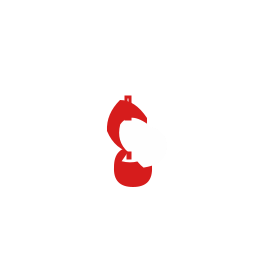

**body_only**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: not well-formed (invalid token): line 3, column 535 | attempt 2: not well-formed (invalid token): line 3, column 535
runtime_seconds: 95.08
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128C108.13 128 92.87 112.87 80 96C69.13 84.13 56 72 44 56C32 40 20 24 12 16C4 -12 20
No valid SVG produced.


**full_svg**

selected_strategy: deterministic
valid_final: True
gate_error: 
runtime_seconds: 22.18
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect width="256" height="256" fill="#000"/>   <g transform="translate(128,128)">     <!-- Flower petals -->     <circle cx="0" cy="0" r="40" fill="#fff" stroke="#ff0000" stroke-width="2"/>     <circle cx="0" c


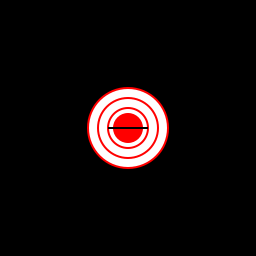

### Train row `thesantatitan_deepseek-svg-dataset_0002993`
**Prompt:** Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code

**Reference SVG**

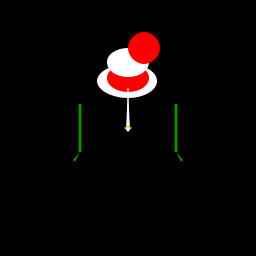

**body_only**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: not well-formed (invalid token): line 3, column 535 | attempt 2: not well-formed (invalid token): line 3, column 535
runtime_seconds: 94.88
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128C108.13 128 92.87 112.87 80 96C69.13 84.13 56 72 44 56C32 40 20 24 12 16C4 -12 20
No valid SVG produced.


**full_svg**

selected_strategy: deterministic
valid_final: True
gate_error: 
runtime_seconds: 21.34
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect width="256" height="256" fill="#000"/>   <g transform="translate(128,128)">     <!-- Flower petals -->     <circle cx="0" cy="0" r="40" fill="#fff" stroke="#ff0000" stroke-width="2"/>     <circle cx="0" c


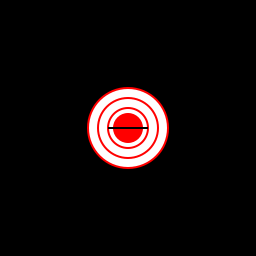

### Train row `thesantatitan_deepseek-svg-dataset_0002140`
**Prompt:** Generate svg code for an image that looks like: the logo for the new logo for the new logo. Don't use markdown just give svg code

**Reference SVG**

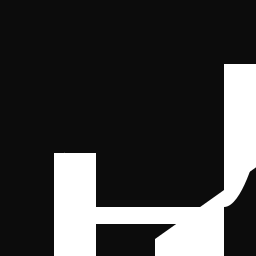

**body_only**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 91.77
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128C108.13 128 96 115.87 96 105.63C96 95.39 108.13 83.26 128 83.26C147.87 83.26 160 


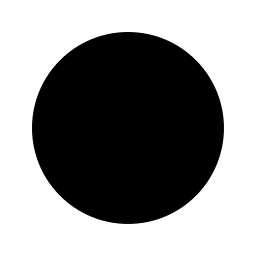

**full_svg**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: unclosed token: line 17, column 2 | attempt 2: unclosed token: line 17, column 2
runtime_seconds: 94.94
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect x="48" y="48" width="172" height="172" fill="#f0f0f0"/>   <circle cx="100" cy="100" r="90" fill="#ff0000"/>   <text x="100" y="100" font-size="48" fill="#ffffff" text-anchor="middle">NEW</text>   <line x1
No valid SVG produced.


### Train row `thesantatitan_deepseek-svg-dataset_0004469`
**Prompt:** Generate svg code for an image that looks like: the logo for the new york hockey club. Don't use markdown just give svg code

**Reference SVG**

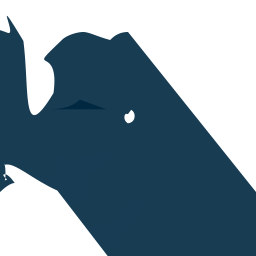

**body_only**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 91.23
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128C108.13 128 96 115.87 96 105.63C96 95.39 108.13 83.26 128 83.26C147.87 83.26 160 


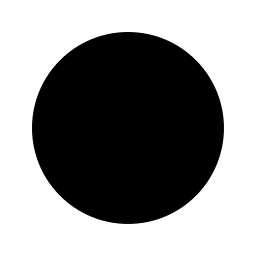

**full_svg**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: unclosed token: line 16, column 2 | attempt 2: unclosed token: line 16, column 2
runtime_seconds: 94.64
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect x="48" y="48" width="172" height="172" fill="#ffcc00"/>   <circle cx="100" cy="100" r="90" fill="#ffffff"/>   <text x="100" y="100" font-size="48" font-weight="bold" fill="#000000">NYH</text>   <line x1="
No valid SVG produced.


### Train row `thesantatitan_deepseek-svg-dataset_0001306`
**Prompt:** Generate svg code for an image that looks like: a person riding a bike. Don't use markdown just give svg code

**Reference SVG**

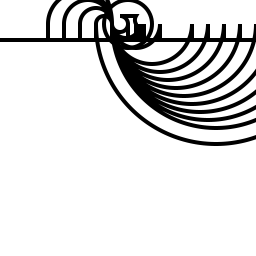

**body_only**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: not well-formed (invalid token): line 3, column 477 | attempt 2: not well-formed (invalid token): line 3, column 477
runtime_seconds: 94.51
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128L128 160C128 160 128 160 128 160C128 160 128 160 128 160C128 160 128 160 128 160C
No valid SVG produced.


**full_svg**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 59.42
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect x="100" y="100" width="100" height="100" fill="#FFD700"/>   <circle cx="128" cy="128" r="20" fill="#000000"/>   <line x1="128" y1="128" x2="128" y2="150" stroke="#000000" stroke-width="2"/> </svg>


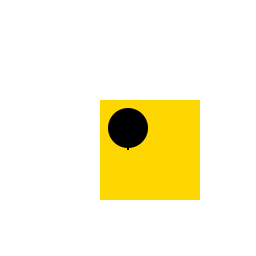

### Train row `thesantatitan_deepseek-svg-dataset_0004543`
**Prompt:** Generate svg code for an image that looks like: the logo for the new logo for the new logo. Don't use markdown just give svg code

**Reference SVG**

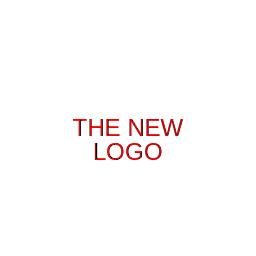

**body_only**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 91.13
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128C108.13 128 96 115.87 96 105.63C96 95.39 108.13 83.26 128 83.26C147.87 83.26 160 


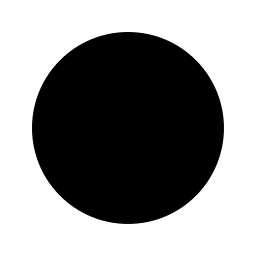

**full_svg**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: unclosed token: line 17, column 2 | attempt 2: unclosed token: line 17, column 2
runtime_seconds: 95.66
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect x="48" y="48" width="172" height="172" fill="#f0f0f0"/>   <circle cx="100" cy="100" r="90" fill="#ff0000"/>   <text x="100" y="100" font-size="48" fill="#ffffff" text-anchor="middle">NEW</text>   <line x1
No valid SVG produced.


### Train row `thesantatitan_deepseek-svg-dataset_0002347`
**Prompt:** Generate svg code for an image that looks like: bitcoin logo. Don't use markdown just give svg code

**Reference SVG**

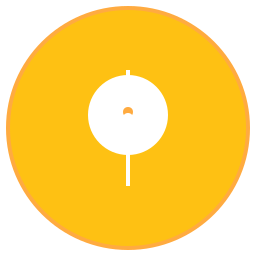

**body_only**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: not well-formed (invalid token): line 6, column 16 | attempt 2: not well-formed (invalid token): line 6, column 16
runtime_seconds: 94.34
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128C108.13 128 96 115.87 96 105.63C96 95.39 108.13 83.26 128 83.26C147.87 83.26 160 
No valid SVG produced.


**full_svg**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 55.35
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect x="0" y="0" width="256" height="256" fill="#ffffff"/>   <circle cx="128" cy="128" r="100" fill="#ff4d4d"/> </svg>


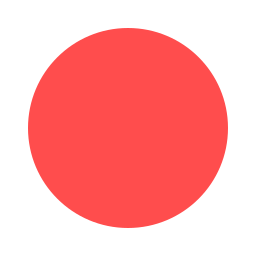

### Train row `thesantatitan_deepseek-svg-dataset_0000877`
**Prompt:** Generate svg code for an image that looks like: the logo for the new film studio. Don't use markdown just give svg code

**Reference SVG**

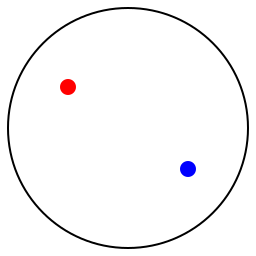

**body_only**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 86.63
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32c-47.9 0-88 38.1-88 88s38.1 88 88 88 88-38.1 88-88-38.1-88-88-88z"/> <path d="M128 32h128v128h-128z"/> <path d="M128 128h128v128h-128z"/> <path d="M128 128h128v128h-128z"/> <path d="M128 128h128v128h-128z"/> <path d="M128 128h128v1


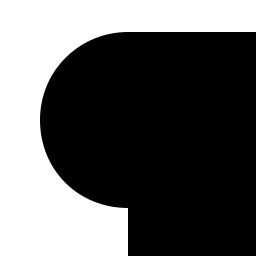

**full_svg**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 94.77
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect x="48" y="48" width="172" height="172" fill="#ffcc00"/>   <circle cx="100" cy="100" r="90" fill="#ffffff"/>   <text x="100" y="100" font-size="48" font-weight="bold" fill="#000000">NewFilmStudio</text>   


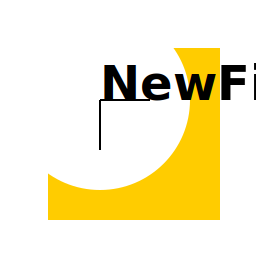

### Train row `thesantatitan_deepseek-svg-dataset_0000387`
**Prompt:** Generate svg code for an image that looks like: the logo for the new app. Don't use markdown just give svg code

**Reference SVG**

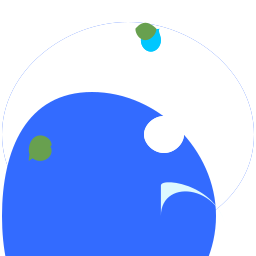

**body_only**

selected_strategy: smoke_test
valid_final: False
gate_error: Failed after 2 attempts. attempt 1: not well-formed (invalid token): line 6, column 52 | attempt 2: not well-formed (invalid token): line 6, column 52
runtime_seconds: 93.92
raw_text snippet: <svg width="256" height="256" viewBox="0 0 256 256"> <path d="M128 32C74.97 32 32 74.97 32 128C32 181.03 74.97 223.97 128 223.97C181.03 223.97 223.97 181.03 223.97 128C223.97 74.97 181.03 32 128 32Z"/> <path d="M128 128C108.13 128 96 115.87 96 105.63C96 95.39 108.13 83.26 128 83.26C147.87 83.26 160 
No valid SVG produced.


**full_svg**

selected_strategy: sampled_repair
valid_final: True
gate_error: 
runtime_seconds: 92.34
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <rect x="48" y="48" width="172" height="172" fill="#f0f0f0"/>   <circle cx="100" cy="100" r="90" fill="#ffcc00"/>   <text x="100" y="100" font-size="48" fill="#ffffff" text-anchor="middle">NEW</text>   <line x1


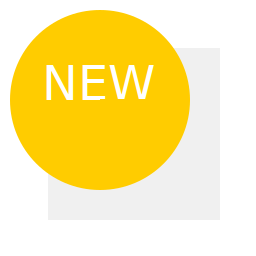

### Train row `398f28b81f30ad686d6188a4162d0766`
**Prompt:** A green circular icon with white bars resembling a graph or chart.

Reference SVG does not pass the current gate; surrogate scores for this row are informational only.


**body_only**

selected_strategy: deterministic
valid_final: True
gate_error: 
runtime_seconds: 11.59
raw_text snippet: <circle cx="128" cy="128" r="100" fill="#4CAF50"/> <path d="M128 32 L128 192" stroke="#FFFFFF" stroke-width="2" fill="none"/> <path d="M128 32 L176 32" stroke="#FFFFFF" stroke-width="2" fill="none"/> <path d="M128 32 L128 160" stroke="#FFFFFF" stroke-width="2" fill="none"/> <path d="M128 32 L128 128


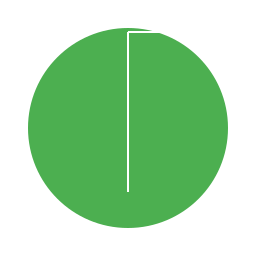

**full_svg**

selected_strategy: deterministic
valid_final: True
gate_error: 
runtime_seconds: 12.81
raw_text snippet: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">   <circle cx="128" cy="128" r="100" fill="#4CAF50"/>   <rect x="90" y="100" width="70" height="40" rx="10" fill="#FFFFFF"/>   <rect x="110" y="100" width="30" height="40" rx="10" fill="#FFFFFF"/>   <rect x="130" 


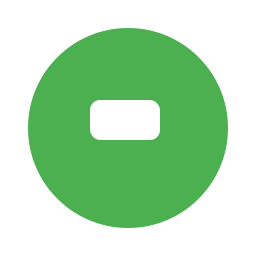

In [10]:
for row in SMOKE_TEST_DF.itertuples(index=False):
    display(Markdown(f"### Train row `{row.id}`\n**Prompt:** {row.prompt}"))
    if bool(row.reference_gate_valid):
        display(Markdown("**Reference SVG**"))
        display(SVG(data=row.svg))
    else:
        print("Reference SVG does not pass the current gate; surrogate scores for this row are informational only.")

    for mode_name, results_df in [("body_only", BODY_ONLY_RESULTS_DF), ("full_svg", FULL_SVG_RESULTS_DF)]:
        candidate = results_df[results_df["id"] == row.id].iloc[0]
        display(Markdown(f"**{mode_name}**"))
        print(f"selected_strategy: {candidate['selected_strategy']}")
        print(f"valid_final: {candidate['valid_final']}")
        print(f"gate_error: {candidate['gate_error']}")
        print(f"runtime_seconds: {candidate['runtime_seconds']:.2f}")
        raw_snippet = candidate['raw_text'].replace("\n", " ")[:300]
        print(f"raw_text snippet: {raw_snippet}")
        if candidate['clean_svg']:
            display(SVG(data=candidate['clean_svg']))
        else:
            print("No valid SVG produced.")
